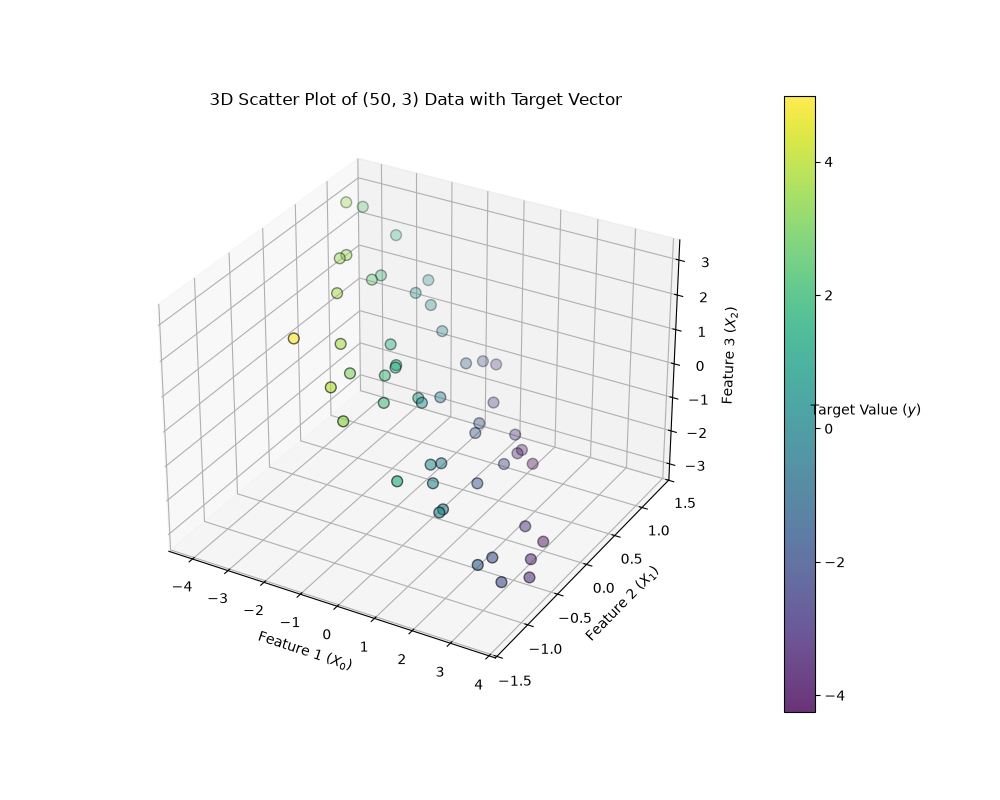

In [5]:
%matplotlib widget
import os
import sys

import matplotlib.pyplot as plt

parent_dir = os.path.abspath("..") # parent root path

if parent_dir not in sys.path:
  sys.path.append(parent_dir)

from tests.data_generator import * 

centered = True # toggle to see the differences

X,y = data_generator()

centered_dataset = []
if centered:
  for _ in X:
    centered_feature = _ - np.mean(_)
    centered_dataset.append(centered_feature)
  X = np.array(centered_dataset) # Making centered dataset

y_flat = y.ravel()
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], 
                     c=y_flat, 
                     cmap='viridis', 
                     s=60, 
                     edgecolor='k', 
                     alpha=0.8)

# 4. Labels and styling
ax.set_title("3D Scatter Plot of (50, 3) Data with Target Vector")
ax.set_xlabel("Feature 1 ($X_0$)")
ax.set_ylabel("Feature 2 ($X_1$)")
ax.set_zlabel("Feature 3 ($X_2$)")

# 5. Add a colorbar to show what the colors represent
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Target Value ($y$)', rotation=0, labelpad=15)

plt.show()

### Implementing PCA for reducing dimensional requirements for given dataset
1. Centering given dataset
2. Finding covariance matrix
3. Eigen vectors and eignen values
4. Making new projection

#### Some critical observations with numpy indices to learn
+ Sorting arrays with respect to one another
+ Making slices and cuts with our requirements

```
pack[:,:k]
```
Means we are taking all rows as it is, but taking columns into range which fits up to 
possible exception out of range

**Indexing flips**
np.argsort(values) # returns just the index required for ascending sort | [::-1] directional flip
values[:, indexing]  # **targeting columns sort now row sort with respect to indexing**


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Util function


# Mock function | for k pick
def k_sub_dimensional(target_matrix,k):
    '''
    input : target matrix
    output: transformation matrix for maping to lower dimension
    '''
    eigen_values, eigen_vectors = np.linalg.eig(target_matrix)
    indx = np.argsort(eigen_values)[::-1]

    eigen_vectors = eigen_vectors[:, indx]  # sorting columns of eigen vector matrix

    return eigen_vectors[:,: k].T 

covariance_matrix = X.T @ X  # shapes d x n n x d -> d x d

maping_vector = k_sub_dimensional(covariance_matrix, 2)
print(f"Maping vector : {maping_vector}, with shape : {maping_vector.shape}")

# We can now Project the original dataset into this new dimension

print(f"Original X : {X.shape}")
projected_dataset = maping_vector @ X.T  # All data points expressed into 2 dimension 
print(f"Projected quantity : {projected_dataset.shape}")




Maping vector : [[-0.75572354+0.j  0.11016521+0.j  0.64555833+0.j]
 [ 0.30910937+0.j -0.80903047+0.j  0.4999211 +0.j]], with shape : (2, 3)
Original X : (50, 3)
Projected quantity : (2, 50)


/home/madhav/workspace/projects/yantragya/.venv/lib64/python3.12/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)


ValueError: s must be float, but has type object